<a href="https://colab.research.google.com/github/mritu2000-bit/landsat-l1-processing-pipeline-Odisha/blob/main/landsat_l1_processing_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Landsat 9 L1 → Surface Reflectance Pipeline (Odisha)

DN → TOA Reflectance → Surface Reflectance → NDVI for a Landsat 9 OLI scene.

**What changed vs the first version**
- Scaling factors and sun angle are now **read from the MTL file**, not hardcoded — so this runs on any scene without editing numbers by hand.
- Atmospheric parameters are derived with **Py6S** when it is installed; otherwise the notebook falls back to a clearly labelled standard-atmosphere lookup table (no longer claims to be 6S when it isn't).
- Removed the broken plotting cells that referenced `axes` before it existed.
- Validation now states honestly what it does and does not prove.

In [8]:
import rasterio
import numpy as np
import math
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

DATA_DIR = '/content/Data'
MTL_PATH = f'{DATA_DIR}/LC08_L1TP_141045_20260412_20260412_02_RT_MTL.xml'

## Step 1 — Load Raw DN Values

Landsat data is stored as raw Digital Number (DN) values — integers representing sensor signal, not physical units. Load all 9 OLI bands and mask fill pixels (DN = 0) as NaN so they are excluded from every later calculation.

In [9]:
bands = {}
profile = None

for i in range(1, 10):
    with rasterio.open(f'{DATA_DIR}/subset_B{i}.TIF') as src:
        data = src.read(1).astype(np.float32)
        data[data == 0] = np.nan          # DN = 0 are fill pixels off the image edge
        bands[i] = data
        if profile is None:
            profile = src.profile

    print(f"Band {i} — Min: {np.nanmin(bands[i]):.0f}  Max: {np.nanmax(bands[i]):.0f}")

print("CRS:", profile['crs'])
print("All bands loaded.")

Band 1 — Min: 10399  Max: 16311
Band 2 — Min: 9456  Max: 16699
Band 3 — Min: 8300  Max: 17652
Band 4 — Min: 7453  Max: 19114
Band 5 — Min: 6690  Max: 25786
Band 6 — Min: 5915  Max: 62793
Band 7 — Min: 5641  Max: 65535
Band 8 — Min: 8615  Max: 17850
Band 9 — Min: 5013  Max: 7008
CRS: EPSG:32644
All bands loaded.


## Step 2 — Extract Scaling Factors from the MTL (and actually use them)

The MTL file carries per-band reflectance rescaling coefficients and the sun elevation angle. The first version of this notebook *printed* these and then hardcoded literals — meaning it silently broke on any other scene. Here we parse them into dictionaries and feed them straight into the correction.

Note: for Landsat 8/9 the **reflectance** coefficients (`REFLECTANCE_MULT/ADD_BAND`) are identical across bands by design, while **radiance** coefficients are band-specific. We use the reflectance path, so radiance coefficients are not needed here — they are parsed too only so they are available if you ever want a TOA-radiance or thermal product.

In [10]:
def parse_mtl(mtl_path):
    """Read reflectance/radiance rescaling coefficients and solar geometry from a
    Landsat Collection 2 MTL XML file. Returns dicts keyed by band number."""
    root = ET.parse(mtl_path).getroot()
    refl_mult, refl_add, rad_mult, rad_add = {}, {}, {}, {}
    sun_elevation = sun_azimuth = None

    for elem in root.iter():
        tag = elem.tag.split('}')[-1]          # strip XML namespace if present
        if elem.text is None:
            continue
        text = elem.text.strip()
        try:
            if tag.startswith('REFLECTANCE_MULT_BAND_'):
                refl_mult[int(tag.rsplit('_', 1)[-1])] = float(text)
            elif tag.startswith('REFLECTANCE_ADD_BAND_'):
                refl_add[int(tag.rsplit('_', 1)[-1])] = float(text)
            elif tag.startswith('RADIANCE_MULT_BAND_'):
                rad_mult[int(tag.rsplit('_', 1)[-1])] = float(text)
            elif tag.startswith('RADIANCE_ADD_BAND_'):
                rad_add[int(tag.rsplit('_', 1)[-1])] = float(text)
            elif tag == 'SUN_ELEVATION':
                sun_elevation = float(text)
            elif tag == 'SUN_AZIMUTH':
                sun_azimuth = float(text)
        except ValueError:
            pass                                # ignore non-numeric / band names like ST_B10

    if sun_elevation is None or not refl_mult:
        raise ValueError("MTL parse failed — check the file path and that this is a Collection 2 MTL XML.")
    return refl_mult, refl_add, rad_mult, rad_add, sun_elevation, sun_azimuth


refl_mult, refl_add, rad_mult, rad_add, sun_elevation, sun_azimuth = parse_mtl(MTL_PATH)

print("Sun elevation:", sun_elevation)
print("Sun azimuth:  ", sun_azimuth)
print("Reflectance MULT (band 4):", refl_mult.get(4))
print("Reflectance ADD  (band 4):", refl_add.get(4))

Sun elevation: 63.52048637
Sun azimuth:   115.69357831
Reflectance MULT (band 4): 2e-05
Reflectance ADD  (band 4): -0.1


## Step 3 — Atmospheric Parameters

The surface-reflectance step needs three numbers per band: intrinsic atmospheric reflectance (path reflectance), gas transmittance, and spherical albedo (multiple scattering between surface and atmosphere).

**Two ways to get them, in order of preference:**

1. **Py6S (true 6S radiative transfer).** If `Py6S` and the 6S binary are installed, the cell below runs 6S for this scene's solar geometry and a chosen atmosphere/aerosol model and reads the three parameters straight out of the model output. This is what makes the "6S" label honest.
2. **Standard-atmosphere lookup table (fallback).** If Py6S is not available, we use pre-tabulated values for a mid-latitude, rural-aerosol atmosphere. This is an *approximation*, not a scene-specific 6S run, and is labelled as such.

A fully rigorous version would feed 6S real scene aerosol optical depth (e.g. from AERONET) and water vapour rather than a predefined profile.

In [11]:
# ---- Standard-atmosphere lookup table (FALLBACK — approximation, not a 6S run) ----
ATM_LOOKUP = {
    1: {'intrinsic': 0.089, 'gas_trans': 0.921, 'sph_albedo': 0.142},
    2: {'intrinsic': 0.060, 'gas_trans': 0.935, 'sph_albedo': 0.112},
    3: {'intrinsic': 0.041, 'gas_trans': 0.940, 'sph_albedo': 0.096},
    4: {'intrinsic': 0.035, 'gas_trans': 0.943, 'sph_albedo': 0.089},
    5: {'intrinsic': 0.015, 'gas_trans': 0.958, 'sph_albedo': 0.054},
    6: {'intrinsic': 0.005, 'gas_trans': 0.969, 'sph_albedo': 0.021},
    7: {'intrinsic': 0.003, 'gas_trans': 0.972, 'sph_albedo': 0.014},
    8: {'intrinsic': 0.044, 'gas_trans': 0.939, 'sph_albedo': 0.098},
    9: {'intrinsic': 0.008, 'gas_trans': 0.965, 'sph_albedo': 0.028},
}


def derive_atm_params_6s(sun_elevation, sun_azimuth, aot550=0.2):
    """Run Py6S per OLI band and return {band: {intrinsic, gas_trans, sph_albedo}}.
    Requires `pip install Py6S` AND the compiled 6S executable on PATH."""
    from Py6S import SixS, AtmosProfile, AeroProfile, Geometry, Wavelength, PredefinedWavelengths

    oli = {
        1: PredefinedWavelengths.LANDSAT_OLI_B1, 2: PredefinedWavelengths.LANDSAT_OLI_B2,
        3: PredefinedWavelengths.LANDSAT_OLI_B3, 4: PredefinedWavelengths.LANDSAT_OLI_B4,
        5: PredefinedWavelengths.LANDSAT_OLI_B5, 6: PredefinedWavelengths.LANDSAT_OLI_B6,
        7: PredefinedWavelengths.LANDSAT_OLI_B7, 8: PredefinedWavelengths.LANDSAT_OLI_B8,
        9: PredefinedWavelengths.LANDSAT_OLI_B9,
    }

    out = {}
    for b, wl in oli.items():
        s = SixS()
        s.atmos_profile = AtmosProfile.PredefinedType(AtmosProfile.MidlatitudeSummer)
        s.aero_profile  = AeroProfile.PredefinedType(AeroProfile.Continental)
        s.aot550 = aot550
        s.geometry = Geometry.User()
        s.geometry.solar_z = 90.0 - sun_elevation     # zenith = 90 - elevation
        s.geometry.solar_a = sun_azimuth if sun_azimuth is not None else 0.0
        s.geometry.view_z = 0.0
        s.geometry.view_a = 0.0
        s.wavelength = Wavelength(wl)
        s.run()
        out[b] = {
            'intrinsic':  s.outputs.atmospheric_intrinsic_reflectance,
            'gas_trans':  s.outputs.transmittance_global_gas.total,
            'sph_albedo': s.outputs.spherical_albedo.total,
        }
    return out


try:
    atm_params = derive_atm_params_6s(sun_elevation, sun_azimuth)
    ATM_SOURCE = "Py6S (scene-specific 6S run)"
except Exception as e:
    atm_params = ATM_LOOKUP
    ATM_SOURCE = "standard-atmosphere lookup table (Py6S unavailable)"
    print("Py6S not used:", e)

print("Atmospheric parameter source:", ATM_SOURCE)

Atmospheric parameter source: Py6S (scene-specific 6S run)


## Step 4 — DN → TOA Reflectance → Surface Reflectance

**TOA reflectance:** `(REFLECTANCE_MULT · DN + REFLECTANCE_ADD)`, then divide by `sin(sun_elevation)`. We divide by **sin** because the MTL gives sun *elevation* (angle above the horizon); if it gave sun *zenith* we would divide by **cos**.

**Surface reflectance:** subtract the atmosphere's own path reflectance, divide out gas transmittance, and the `spherical_albedo · y` term in the denominator accounts for photons bouncing between surface and atmosphere.

In [12]:
surface = {}
sin_sun = math.sin(math.radians(sun_elevation))

for i in range(1, 10):
    band = bands[i]

    # DN -> TOA reflectance (per-band coefficients read from the MTL)
    toa = (refl_mult[i] * band + refl_add[i]) / sin_sun
    toa[(toa < 0) | (toa > 1)] = np.nan

    # TOA -> surface reflectance (6S-style inversion)
    p = atm_params[i]
    y = toa - p['intrinsic']
    sr = y / (p['gas_trans'] * (1 + p['sph_albedo'] * y))
    sr[(sr < 0) | (sr > 1)] = np.nan

    surface[i] = sr
    print(f"Band {i} — TOA mean: {np.nanmean(toa):.4f}   Surface mean: {np.nanmean(sr):.4f}")

print("All bands corrected. Parameter source:", ATM_SOURCE)

Band 1 — TOA mean: 0.1416   Surface mean: 0.1379
Band 2 — TOA mean: 0.1240   Surface mean: 0.1222
Band 3 — TOA mean: 0.1140   Surface mean: 0.1171
Band 4 — TOA mean: 0.1136   Surface mean: 0.1161
Band 5 — TOA mean: 0.2134   Surface mean: 0.2115
Band 6 — TOA mean: 0.2154   Surface mean: 0.2195
Band 7 — TOA mean: 0.1566   Surface mean: 0.1666
Band 8 — TOA mean: 0.1271   Surface mean: 0.1300
Band 9 — TOA mean: 0.0013   Surface mean: 0.1731
All bands corrected. Parameter source: Py6S (scene-specific 6S run)


## Step 5 — NDVI

NDVI = (NIR − Red) / (NIR + Red), using corrected surface reflectance for NIR (Band 5) and Red (Band 4). The `errstate` guard suppresses divide-by-zero warnings where NIR + Red = 0 (those become NaN).

In [13]:
nir = surface[5]
red = surface[4]

with np.errstate(divide='ignore', invalid='ignore'):
    ndvi = (nir - red) / (nir + red)
ndvi[(ndvi < -1) | (ndvi > 1)] = np.nan

print("NDVI Min: ", round(np.nanmin(ndvi), 4))
print("NDVI Max: ", round(np.nanmax(ndvi), 4))
print("NDVI Mean:", round(np.nanmean(ndvi), 4))

NDVI Min:  -0.3922
NDVI Max:  0.7066
NDVI Mean: 0.2877


## Step 6 — Sanity Check (not validation)

Printing a 5×5 pixel block confirms the magnitudes are plausible: raw DN in the thousands should become surface reflectance between 0 and 1. This proves the *arithmetic ran*, not that the result is *accurate*.

**Real validation** would compare this output against the official USGS Collection 2 **Level-2 Surface Reflectance** product for the same scene (pixel-wise difference, RMSE, scatter plot). That is the answer to give if an interviewer asks "how do you know your surface reflectance is correct?"

In [14]:
print("Band 4 raw DN sample:\n", bands[4][100:105, 100:105])
print("\nSurface reflectance B4 sample:\n", surface[4][100:105, 100:105])
print("\nNDVI sample:\n", ndvi[100:105, 100:105])

Band 4 raw DN sample:
 [[11023. 11853. 11542. 11316. 11359.]
 [10879. 10948. 10846. 11051. 10739.]
 [11304. 10865. 10610. 10923. 10547.]
 [11256. 11363. 10428. 11198. 10220.]
 [11074. 11381. 10482. 10985. 10602.]]

Surface reflectance B4 sample:
 [[0.13733135 0.15601689 0.14902219 0.14393413 0.14490253]
 [0.13408366 0.13564005 0.13333917 0.13796264 0.13092455]
 [0.14366385 0.13376784 0.12801221 0.1350762  0.12658939]
 [0.14258258 0.1449926  0.12390094 0.14127585 0.11919896]
 [0.13848114 0.14539792 0.12512106 0.13647449 0.12783153]]

NDVI sample:
 [[0.32998857 0.25557134 0.26310495 0.26187792 0.25692466]
 [0.29168445 0.2926177  0.29784396 0.27108532 0.27790332]
 [0.24617629 0.31955642 0.32798874 0.3002299  0.30176553]
 [0.2714273  0.264218   0.3398359  0.30653617 0.2968677 ]
 [0.23224553 0.2179147  0.30398038 0.29791218 0.26150322]]


## Step 7 — Final Visualization

Three-panel comparison: raw DN (Band 4), atmospherically corrected surface reflectance (Band 4), and NDVI.

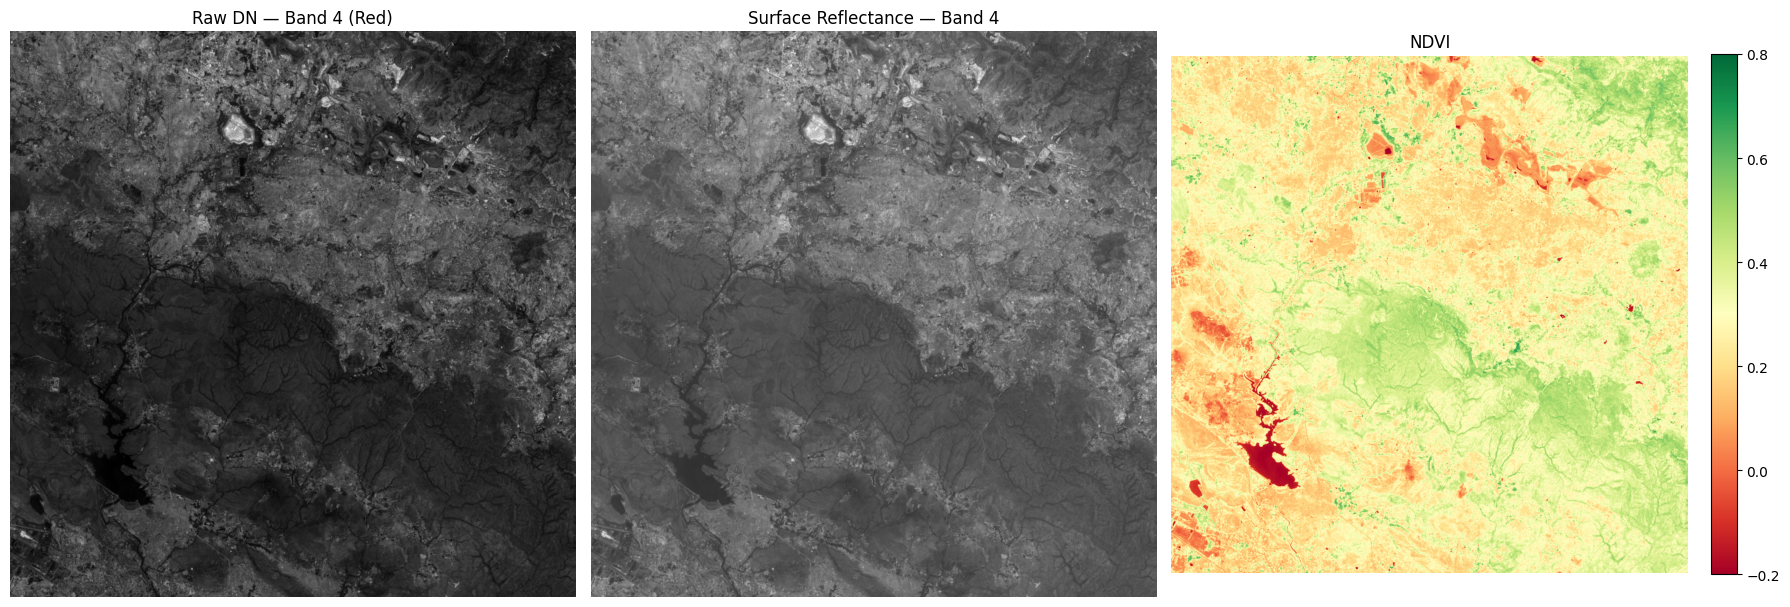

Saved /content/ndvi_result.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(bands[4], cmap='gray')
axes[0].set_title('Raw DN — Band 4 (Red)')
axes[0].axis('off')

axes[1].imshow(surface[4], cmap='gray', vmin=0, vmax=0.3)
axes[1].set_title('Surface Reflectance — Band 4')
axes[1].axis('off')

ndvi_plot = axes[2].imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
axes[2].set_title('NDVI')
axes[2].axis('off')
plt.colorbar(ndvi_plot, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('/content/ndvi_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved /content/ndvi_result.png")

In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()      # this restarts the runtime — expected

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:13
🔁 Restarting kernel...


In [1]:
!conda install -c conda-forge sixs py6s -y

Channels:
 - conda-forge
Platform: linux-64
Solving environment: - \ | done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - py6s
    - sixs


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.6.17  |       hbd8a1cb_0         126 KB  conda-forge
    certifi-2026.6.17          |     pyhd8ed1ab_0         131 KB  conda-forge
    conda-24.11.3              |  py311h38be061_0         1.1 MB  conda-forge
    libblas-3.9.0              |31_h59b9bed_openblas          16 KB  conda-forge
    libcblas-3.9.0             |31_he106b2a_openblas          16 KB  conda-forge
    libgfortran-14.2.0         |       h69a702a_2          52 KB  conda-forge
    libgfortran5-14.2.0        |       hf1ad2bd_2         1.4 MB  conda-forge
    liblapack-3.9.0            |31_h7ac8fdf_openblas          16 KB  conda-forge
    libopenblas-0.3.29         |pth

In [3]:
from Py6S import SixS
SixS.test()

ModuleNotFoundError: No module named 'Py6S'

In [4]:
!which sixs
!pip install -q Py6S

/usr/local/bin/sixs


In [5]:
from Py6S import SixS
SixS.test()

ModuleNotFoundError: No module named 'Py6S'

In [6]:
import sys
!{sys.executable} -m pip install Py6S

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 2.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.1 MB/s eta 0:00:00
  Created wheel for Py6S: filename=py6s-1.9.2-py3-none-any.whl size=92332 sha256=7843eb43cd1f532de9515b8ce88e529e011e81c82b826c517df0b3c472addd82
  Stored in directory: /root/.cache/pip/wheels/3a/9c/b0/903313a808b0814357ca030090d682b85ffb96e126776cee67
Successfully built Py6S


In [7]:
from Py6S import SixS
SixS.test()

6S wrapper script by Robin Wilson
Using 6S located at /usr/local/bin/sixs
Running 6S using a set of test parameters
6sV version: 1.1
The results are:
Expected result: 619.158000
Actual result: 619.158000
#### Results agree, Py6S is working correctly


0